<a href="https://colab.research.google.com/github/KaveenKK/Neural_Network/blob/main/Neural_Network_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep Stage Classification using Accelerometer Data

This notebook demonstrates an end-to-end pipeline for classifying sleep stages (Sleep vs. Awake) using 3-axis accelerometer data. The final model is optimized and converted to a C header file for deployment on microcontrollers (Edge AI).

To analazy if the patient or the adult person is asleep, awake or walking at the current movement

In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sbn
from scipy import stats
import math
from tensorflow.keras import layers



%matplotlib inline

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
# Print versions
print('TensorFlow ' + tf.__version__)


TensorFlow 2.19.0


In [ ]:
"file_path = 'Accelerometer_data_sleeptracking.csv'\n"

# Read the Excel file into a pandas DataFrame
df = pd.read_csv(file_path)


df.head()


,X_Acc,Y_Acc,Z_Acc,Sleep_Stage
0,X-Acceleration: 0.00 g,Y-Acceleration: 0.09 g,Z-Acceleration: 1.42 g,Sleep
1,X-Acceleration: 0.02 g,Y-Acceleration: 0.10 g,Z-Acceleration: 1.42 g,Sleep
2,X-Acceleration: 0.01 g,Y-Acceleration: 0.09 g,Z-Acceleration: 1.42 g,Sleep
3,X-Acceleration: 0.02 g,Y-Acceleration: 0.09 g,Z-Acceleration: 1.43 g,Sleep
4,X-Acceleration: 0.02 g,Y-Acceleration: 0.09 g,Z-Acceleration: 1.43 g,Sleep


In [ ]:
# summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   X_Acc        182 non-null    object
 1   Y_Acc        182 non-null    object
 2   Z_Acc        182 non-null    object
 3   Sleep_Stage  182 non-null    object
dtypes: object(4)
memory usage: 5.8+ KB


**Cleaning the Dataset and Preprocessing**

### Feature Engineering: Calculating Deltas
Instead of using raw acceleration, we calculate the 'Delta' (difference) between consecutive readings. This helps the model focus on **movement intensity** rather than the static orientation of the device.

In [ ]:
import re

# Expression to match numbers with decimals, plus and minus signs
pattern = re.compile(r'[-+]?\d*\.?\d+')
# Function to extract numbers from each string
def extract_numbers(text):
    return ''.join(pattern.findall(text))

# Applying the function to each column in the DataFrame
for column in df.columns:
    df['X_Acc'] = df['X_Acc'].apply(extract_numbers)
    df['Y_Acc'] = df['Y_Acc'].apply(extract_numbers)
    df['Z_Acc'] = df['Z_Acc'].apply(extract_numbers)



print(df)




     X_Acc Y_Acc Z_Acc Sleep_Stage
0     0.00  0.09  1.42       Sleep
1     0.02  0.10  1.42       Sleep
2     0.01  0.09  1.42       Sleep
3     0.02  0.09  1.43       Sleep
4     0.02  0.09  1.43       Sleep
..     ...   ...   ...         ...
177  -0.19  0.07  1.04       Awake
178   0.23  0.21  1.31       Awake
179   0.11  0.40  1.35       Awake
180  -0.10  0.28  1.42       Awake
181  -0.11  0.35  1.38       Awake

[182 rows x 4 columns]


In [ ]:
df.head()

,X_Acc,Y_Acc,Z_Acc,Sleep_Stage
0,0.00,0.09,1.42,Sleep
1,0.02,0.10,1.42,Sleep
2,0.01,0.09,1.42,Sleep
3,0.02,0.09,1.43,Sleep
4,0.02,0.09,1.43,Sleep


In [ ]:
#converting into float

df['X_Acc'] = df['X_Acc'].astype(float)
df['Y_Acc'] = df['Y_Acc'].astype(float)
df['Z_Acc'] = df['Z_Acc'].astype(float)
print(df.dtypes)


X_Acc          float64
Y_Acc          float64
Z_Acc          float64
Sleep_Stage     object
dtype: object


In [ ]:
print(df)

print(df.dtypes)

     X_Acc  Y_Acc  Z_Acc Sleep_Stage
0     0.00   0.09   1.42       Sleep
1     0.02   0.10   1.42       Sleep
2     0.01   0.09   1.42       Sleep
3     0.02   0.09   1.43       Sleep
4     0.02   0.09   1.43       Sleep
..     ...    ...    ...         ...
177  -0.19   0.07   1.04       Awake
178   0.23   0.21   1.31       Awake
179   0.11   0.40   1.35       Awake
180  -0.10   0.28   1.42       Awake
181  -0.11   0.35   1.38       Awake

[182 rows x 4 columns]
X_Acc          float64
Y_Acc          float64
Z_Acc          float64
Sleep_Stage     object
dtype: object


Exploratory Data Analysis

In [ ]:
#sleep counts
SleepCounts = df['Sleep_Stage'].value_counts()
print(SleepCounts)

Sleep_Stage
Awake    109
Sleep     73
Name: count, dtype: int64


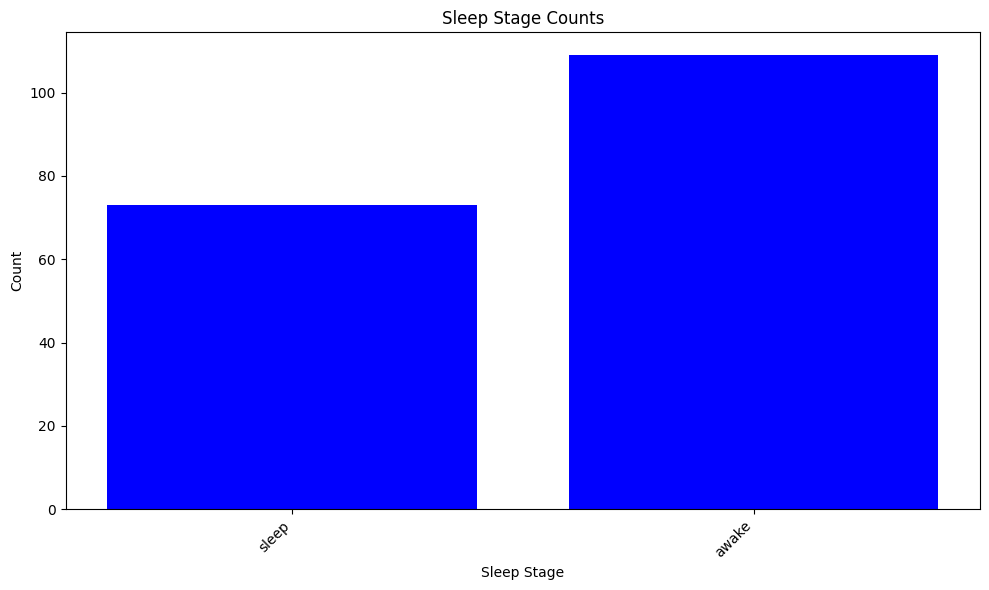

In [ ]:
activities = ['sleep', 'awake']
counts = [73, 109]

# Create a bar plot
plt.figure(figsize=(10, 6))  # Set the figure size
plt.bar(activities, counts, color='blue')  # Create the bar plot
plt.xlabel('Sleep Stage')  # Label for x-axis
plt.ylabel('Count')  # Label for y-axis
plt.title('Sleep Stage Counts')  # Title for the plot
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout
plt.show()  # Show the plot


In [ ]:

#in order to convert the model into C
! pip install "everywhereml>=0.2.32"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 669.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 2.9 MB/s eta 0:00:00
  Created wheel for everywhereml: filename=everywhereml-0.2.40-py3-none-any.whl size=81188 sha256=af0cd6dca8b893fd9b2b51b0f956eae083003fb99ac369e5ba75273ad0ce9f86
  Stored in directory: /root/.cache/pip/wheels/9f/c0/e7/aa2777ca6fe0c062e0ba46fb79c045cfc22c968df0f4296b8f
  Created wheel for hexdump: filename=hexdump-3.3-py3-none-any.whl size=8894 sha256=2736ccd3bae287d9495f344836592477ee54990b95b21730ea5a631f3e2cab3d
  Stored in directory: /root/.cache/pip/wheels/5e/b9/b5/227a20e7e8bbdb2b17e46a087c0f0119059ee65fe8374cac18
Successfully built everywhereml hexdump


In [ ]:
print(df['X_Acc'])
print(df['Y_Acc'])
print(df['Z_Acc'])

0      0.00
1      0.02
2      0.01
3      0.02
4      0.02
       ... 
177   -0.19
178    0.23
179    0.11
180   -0.10
181   -0.11
Name: X_Acc, Length: 182, dtype: float64
0      0.09
1      0.10
2      0.09
3      0.09
4      0.09
       ... 
177    0.07
178    0.21
179    0.40
180    0.28
181    0.35
Name: Y_Acc, Length: 182, dtype: float64
0      1.42
1      1.42
2      1.42
3      1.43
4      1.43
       ... 
177    1.04
178    1.31
179    1.35
180    1.42
181    1.38
Name: Z_Acc, Length: 182, dtype: float64


In [ ]:
# Calculate delta values
df['delta_x'] = df['X_Acc'].diff().fillna(0)
df['delta_y'] = df['Y_Acc'].diff().fillna(0)
df['delta_z'] = df['Z_Acc'].diff().fillna(0)

In [ ]:
print(df['delta_x'])
print(df['delta_y'])
print(df['delta_z'])

0      0.00
1      0.02
2     -0.01
3      0.01
4      0.00
       ... 
177   -0.42
178    0.42
179   -0.12
180   -0.21
181   -0.01
Name: delta_x, Length: 182, dtype: float64
0      0.00
1      0.01
2     -0.01
3      0.00
4      0.00
       ... 
177   -0.27
178    0.14
179    0.19
180   -0.12
181    0.07
Name: delta_y, Length: 182, dtype: float64
0      0.00
1      0.00
2      0.00
3      0.01
4      0.00
       ... 
177   -0.31
178    0.27
179    0.04
180    0.07
181   -0.04
Name: delta_z, Length: 182, dtype: float64


In [ ]:
print(df)

     X_Acc  Y_Acc  Z_Acc Sleep_Stage  delta_x  delta_y  delta_z
0     0.00   0.09   1.42       Sleep     0.00     0.00     0.00
1     0.02   0.10   1.42       Sleep     0.02     0.01     0.00
2     0.01   0.09   1.42       Sleep    -0.01    -0.01     0.00
3     0.02   0.09   1.43       Sleep     0.01     0.00     0.01
4     0.02   0.09   1.43       Sleep     0.00     0.00     0.00
..     ...    ...    ...         ...      ...      ...      ...
177  -0.19   0.07   1.04       Awake    -0.42    -0.27    -0.31
178   0.23   0.21   1.31       Awake     0.42     0.14     0.27
179   0.11   0.40   1.35       Awake    -0.12     0.19     0.04
180  -0.10   0.28   1.42       Awake    -0.21    -0.12     0.07
181  -0.11   0.35   1.38       Awake    -0.01     0.07    -0.04

[182 rows x 7 columns]


Splitting dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np



# Define features (X) and target (y)
X = df.drop(columns=["Sleep_Stage", "X_Acc", "Y_Acc", "Z_Acc"])  # Features
X = np.asarray(X)



y = df["Sleep_Stage"]  # Target
y_array = np.array(y)
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y_array.reshape(-1, 1))
# Convert the encoded result to integer type
y_encoded = y_encoded.astype(int)
#Printing the shapes to confirm transformation
print("Shape of y_array:", y_array.shape)
print("Shape of y_encoded:", y_encoded.shape)
y= y_encoded

# Print the encoded array
print("Encoded y:", y)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

Shape of y_array: (182,)
Shape of y_encoded: (182, 2)
Encoded y: [[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 

In [ ]:

print(y)


[[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]

In [ ]:
#defining my model
def model_structure(input_shape, num_classes):
  model = tf.keras.Sequential()
  model.add(layers.Dense(32, activation='relu', input_shape=input_shape))
  model.add(layers.Dense(16, activation='relu'))
  model.add(layers.Dense(num_classes, activation='softmax'))
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


  return model

### Model Architecture
We use a Simple Feed-Forward Neural Network (Multi-Layer Perceptron).
- **Input Layer**: 3 features (Delta X, Y, Z).
- **Hidden Layers**: Dense layers with ReLU activation to capture non-linear patterns of movement.
- **Output Layer**: Softmax activation for 2-class classification (Sleep/Awake).

In [ ]:
print(y.dtype)


int64


In [ ]:
# Train model
input_shape = X.shape[1:]
num_classes = y.shape[1]
print("Shape of X:", X.shape)#shape of X
print("Shape of y:", y.shape)
model = model_structure(input_shape, num_classes)
history = model.fit(X_train, y_train, epochs=400, batch_size=10)


Shape of X: (182, 3)
Shape of y: (182, 2)
Epoch 1/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5034 - loss: 0.6817
Epoch 2/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5931 - loss: 0.6394
Epoch 3/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5931 - loss: 0.6078
Epoch 4/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5931 - loss: 0.5815
Epoch 5/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5931 - loss: 0.5582 
Epoch 6/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5931 - loss: 0.5356 
Epoch 7/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5931 - loss: 0.5158 
Epoch 8/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5931 - loss: 0.4952 
Epoch 9/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5931 - loss: 0.4766 
Epoch 10/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7172 - loss: 0.4595 
Epoch 11/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9379 - loss: 0.4416 
Epoch 12/4

In [ ]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import numpy as np


# Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Calculate the accuracy
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy:.2f}")

# Generate and display a confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Display a classification report
class_report = classification_report(true_classes, predicted_classes)
print("Classification Report:")
print(class_report)



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Accuracy: 0.97
Confusion Matrix:
[[22  1]
 [ 0 14]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.93      1.00      0.97        14

    accuracy                           0.97        37
   macro avg       0.97      0.98      0.97        37
weighted avg       0.97      0.97      0.97        37



In [ ]:
# Save the model with a .keras extension
model.save('/content/drive.keras')


In [ ]:
# Convert the model to tf lite.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpfoi8n0oi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134606365648720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365653328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651984: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# Save the model as a tflite file.
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)


### Deployment: Edge AI Conversion
To run this on an Arduino or ESP32, we convert the TensorFlow Lite model into a **C Byte Array**. This allows the model to be compiled directly into the firmware of a low-power device.

In [ ]:
# Convert TFLite model to C byte array without everywhereml
!xxd -i model.tflite > mymodel_data.h


In [ ]:
from everywhereml.code_generators.tensorflow import convert_model
#checks the shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)



#convert to C model file
c_header = convert_model(model, X, y, model_name='SleepStage_model')
print(c_header)

Shape of X: (182, 3)
Shape of y: (182, 2)
Saved artifact at '/tmp/tmp_qkxnm1z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134606365648720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365653328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134606365651984: TensorSpec(shape=(), dtype=tf.resource, name=None)
#pragma once

#ifdef __has_attribute
#define HAVE_ATTRIBUTE(x) __has_attribute(x)
#else
#define HAVE_ATTRIBUTE(x) 0
#endif
#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))
#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))
#else
#def